# 01 Importing Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# 02 Import Data

In [2]:
path = r'C:\Users\isava\OneDrive\Documents\CareerFoundry\Data Immersion\PythonFundamentals\Instacart Basket Analysis'
path

'C:\\Users\\isava\\OneDrive\\Documents\\CareerFoundry\\Data Immersion\\PythonFundamentals\\Instacart Basket Analysis'

In [3]:
df = pd.read_pickle(os.path.join(path,'02 Data', 'Prepared Data','ords_prods_custs.pkl'))
dep_df = pd.read_csv(os.path.join(path,'02 Data', 'Prepared Data','departments_wrangled.csv'))

In [5]:
df.head()

,order_id,user_id,order_number,orders_day_of_week,order_time_of_day,days_since_users_prior_order,product_id,add_to_cart_order,reordered,_merge,...,first_name,last_name,gender,state,age,date_joined,n_dependents,fam_status,income,_custMerge
0,2539329,1,1,2,8,NaN,196,1,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,both
1,3367565,1,6,2,7,19.0,25133,4,1,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,both
2,550135,1,7,1,9,20.0,196,1,1,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,both
3,550135,1,7,1,9,20.0,10258,2,1,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,both
4,550135,1,7,1,9,20.0,12427,3,1,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,both


In [8]:
dep_df.head()

,Unnamed: 0,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


# 03 Security

Personally Identifiable Information (PII) is any data that could reveal a persons identity or personal information. Some potential PII in this data set is:

- Name
- Gender
- State
- Age
- Familial Status
- Number of Dependents
- Income

Some of this information may not considered to be PII on its own, such as gender or age, but in combination with other columns, such as age, dependents, income, the data becomes PII because it could be used to identify an individual. We must be careful that this data is shared to individuals with clearance to view the data and with proper training on PII. If needed to share, there are methods to scrub the PII from the dataset. In this case the customer data is fabricated so we can continue with sharing it but it is something to be weary of. 

# 04 Deriving New Variables and Visualizations

## Regions

In [7]:
northeast_states = ['Maine', 'New Hampshire', 'Vermont', 'Massachusetts', 'Rhode Island', 'Connecticut', 'New York', 'Pennsylvania', 'New Jersey'] 
midwest_states = ['Wisconsin', 'Michigan', 'Illinois', 'Indiana', 'Ohio', 'North Dakota', 'South Dakota', 'Nebraska', 'Kansas', 'Minnesota', 'Iowa', 'Missouri'] 
south_states = ['Delaware', 'Maryland', 'District of Columbia', 'Virginia', 'West Virginia', 'North Carolina', 'South Carolina', 'Georgia', 'Florida', 'Kentucky', 'Tennessee', 'Mississippi', 'Alabama', 'Oklahoma', 'Texas', 'Arkansas', 'Louisiana'] 
west_states = ['Idaho', 'Montana', 'Wyoming', 'Nevada', 'Utah', 'Colorado', 'Arizona', 'New Mexico', 'Alaska', 'Washington', 'Oregon', 'California', 'Hawaii'] 
df.loc[df['state'].isin(northeast_states), 'region'] = 'Northeast' 
df.loc[df['state'].isin(midwest_states), 'region'] = 'Midwest' 
df.loc[df['state'].isin(south_states), 'region'] = 'South' 
df.loc[df['state'].isin(west_states), 'region'] = 'West' 
df.loc[~df['state'].isin(northeast_states + midwest_states + south_states + west_states), 'region'] = 'Unable to locate'

In [10]:
#Check to make sure there are none defined as 'Unable to locate'
df['region'].value_counts(dropna = False)

region
South        10791885
West          8292913
Midwest       7597325
Northeast     5722736
Name: count, dtype: int64

### Exclusion Flag

Create an exclusion flag for low-activity customers (< 5 orders) and exclude

In [9]:
df['max_no_of_orders'] = df.groupby(['user_id'])['order_number'].transform('max')
df.loc[df['max_no_of_orders'] > 5, 'exclusion_flag'] = 'High Activity Customer' 
df.loc[df['max_no_of_orders'] <= 5, 'exclusion_flag'] = 'Low Activity Customer' 
df['exclusion_flag'].value_counts(dropna = False)

exclusion_flag
High Activity Customer    30171424
Low Activity Customer      2233435
Name: count, dtype: int64

In [11]:
df_high_activity = df[df['exclusion_flag'] == 'High Activity Customer']
df_high_activity['exclusion_flag'].value_counts(dropna = False)

exclusion_flag
High Activity Customer    30171424
Name: count, dtype: int64

## Customer Profiles

### Demographics

In [16]:
df_high_activity.head()

,order_id,user_id,order_number,orders_day_of_week,order_time_of_day,days_since_users_prior_order,product_id,add_to_cart_order,reordered,_merge,...,state,age,date_joined,n_dependents,fam_status,income,_custMerge,region,max_no_of_orders,exclusion_flag
0,2539329,1,1,2,8,NaN,196,1,0,both,...,Alabama,31,2/17/2019,3,married,40423,both,South,10,High Activity Customer
1,3367565,1,6,2,7,19.0,25133,4,1,both,...,Alabama,31,2/17/2019,3,married,40423,both,South,10,High Activity Customer
2,550135,1,7,1,9,20.0,196,1,1,both,...,Alabama,31,2/17/2019,3,married,40423,both,South,10,High Activity Customer
3,550135,1,7,1,9,20.0,10258,2,1,both,...,Alabama,31,2/17/2019,3,married,40423,both,South,10,High Activity Customer
4,550135,1,7,1,9,20.0,12427,3,1,both,...,Alabama,31,2/17/2019,3,married,40423,both,South,10,High Activity Customer


In [17]:
df_high_activity['fam_status'].value_counts()

fam_status
married                             21188130
single                               4961333
divorced/widowed                     2577880
living with parents and siblings     1444081
Name: count, dtype: int64

I will create the following customer profiles

- 18-30, no dependents, not married: single young adult
- 30 - 50, no dependents, not married: single adult
- 50 - 75, no dependents, not married: single older adult
- 75+, no dependents, not married: single elder
- 18-30, no dependents,  married: young couple
- 30 - 50, no dependents,  married: couple
- 50 - 75, no dependents,  married: older couple
- 75+, 1+ dependents,  married: elderly couple
- 18-30, 1+ dependents: young family
- 30 - 50, 1+ dependents: family
- 50 - 75, 1+ dependents: older family
- 75+, 1+ dependents: elderly family

In [13]:
##Single
df_high_activity.loc[(df_high_activity['age'] >= 18) & (df_high_activity['age'] <= 30) & (df_high_activity['fam_status'] != 'married') & (df_high_activity['n_dependents'] == 0), 'profile'] = 'Single Young Adult' 
df_high_activity.loc[(df_high_activity['age'] >= 31) & (df_high_activity['age'] <= 50) & (df_high_activity['fam_status'] != 'married') & df_high_activity['n_dependents'] == 0, 'profile'] = 'Single Adult' 
df_high_activity.loc[(df_high_activity['age'] >= 51) & (df_high_activity['age'] <= 75) & (df_high_activity['fam_status'] != 'married') & df_high_activity['n_dependents'] == 0, 'profile'] = 'Single Older Adult' 
df_high_activity.loc[(df_high_activity['age'] >= 76) & (df_high_activity['fam_status'] != 'married') & (df_high_activity['n_dependents'] == 0), 'profile'] = 'Single Elder' 
##Married
df_high_activity.loc[(df_high_activity['age'] >= 18) & (df_high_activity['age'] <= 30) & (df_high_activity['fam_status'] == 'married') & df_high_activity['n_dependents'] == 0, 'profile'] = 'Young Couple' 
df_high_activity.loc[(df_high_activity['age'] >= 31) & (df_high_activity['age'] <= 50) & (df_high_activity['fam_status'] == 'married') & df_high_activity['n_dependents'] == 0, 'profile'] = 'Adult Couple' 
df_high_activity.loc[(df_high_activity['age'] >= 51) & (df_high_activity['age'] <= 75) & (df_high_activity['fam_status'] == 'married') & df_high_activity['n_dependents'] == 0, 'profile'] = 'Older Adult Couple' 
df_high_activity.loc[(df_high_activity['age'] >= 76) & (df_high_activity['fam_status'] == 'married') & (df_high_activity['n_dependents'] == 0), 'profile'] = 'Elderly Couple' 
##Children (married or not)
df_high_activity.loc[(df_high_activity['age'] >= 18) & (df_high_activity['age'] <= 30) & (df_high_activity['n_dependents'] > 0), 'profile'] = 'Young Family' 
df_high_activity.loc[(df_high_activity['age'] >= 31) & (df_high_activity['age'] <= 50) & (df_high_activity['n_dependents'] > 0), 'profile'] = 'Adult Family' 
df_high_activity.loc[(df_high_activity['age'] >= 51) & (df_high_activity['age'] <= 75) & (df_high_activity['n_dependents'] > 0), 'profile'] = 'Older Adult Family' 
df_high_activity.loc[(df_high_activity['age'] >= 76) & (df_high_activity['n_dependents'] > 0), 'profile'] = 'Elderly Family' 

C:\Users\isava\AppData\Local\Temp\ipykernel_18772\411382132.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_high_activity.loc[(df_high_activity['age'] >= 18) & (df_high_activity['age'] <= 30) & (df_high_activity['fam_status'] != 'married') & (df_high_activity['n_dependents'] == 0), 'profile'] = 'Single Young Adult'


In [15]:
#df_high_activity['profile'].value_counts(dropna = False)
df_high_activity.groupby('profile')['user_id'].nunique()

profile
Adult Family          34227
Elderly Family        10481
Older Adult Couple    36628
Older Adult Family    42915
Young Family          22215
Name: user_id, dtype: int64

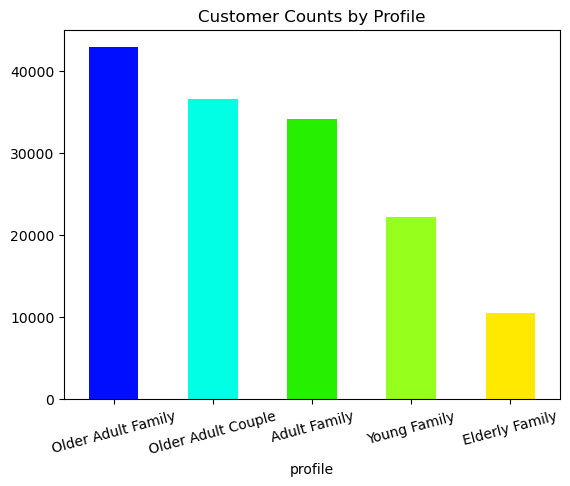

In [23]:
palette = sns.color_palette("gist_ncar", 8)

bar = df_high_activity.groupby('profile')['user_id'].nunique().sort_values(ascending = False).plot.bar(title = 'Customer Counts by Profile', rot = 15, color = palette)
plt.show()

In [25]:
bar.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_fam_profiles.png'), bbox_inches = "tight")

In [29]:
df_high_activity.columns.tolist()

['order_id',
 'user_id',
 'order_number',
 'orders_day_of_week',
 'order_time_of_day',
 'days_since_users_prior_order',
 'product_id',
 'add_to_cart_order',
 'reordered',
 '_merge',
 'product_name',
 'aisle_id',
 'department_id',
 'prices',
 '_prodMerge',
 'price_range_loc',
 'busiest_day',
 'busiest_days',
 'busiest_period_of_day',
 'max_order',
 'loyalty_flag',
 'avg_spending',
 'spending_flag',
 'median_order_frequency',
 'order_frequency_flag',
 'first_name',
 'last_name',
 'gender',
 'state',
 'age',
 'date_joined',
 'n_dependents',
 'fam_status',
 'income',
 '_custMerge',
 'region',
 'max_no_of_orders',
 'exclusion_flag',
 'profile']

In [30]:
df_high_activity.groupby('profile').agg({'avg_spending': ['max', 'mean', 'min']})

avg_spending                     
                             max       mean       min
profile                                              
Adult Family         5271.136842  11.638859  1.000000
Elderly Family       2270.344796  11.614552  1.933333
Older Adult Couple  15006.940000  12.081944  1.100000
Older Adult Family   6389.512766  11.883806  1.262500
Young Family        10209.987755  11.893951  1.900000

In [31]:
df_high_activity.groupby('profile').agg({'median_order_frequency': ['max','mean', 'min']})

median_order_frequency               
                                      max      mean  min
profile                                                 
Adult Family                         30.0  9.675549  0.0
Elderly Family                       30.0  9.732165  0.0
Older Adult Couple                   30.0  9.680553  0.0
Older Adult Family                   30.0  9.763646  0.0
Young Family                         30.0  9.681521  0.0

Older Adult Families order the most items from instacart. They are also the most frequent users and the highest spenders. Interestingly we see single categories using instacart. The main chunk of activity is by families and older adult couples. 

### Regions

In [33]:
df_high_activity.groupby(['region','profile']).agg({'avg_spending': ['max', 'mean', 'min']})

avg_spending                     
                                       max       mean       min
region    profile                                              
Midwest   Adult Family         3549.811989  12.659655  1.000000
          Elderly Family       2270.344796  12.252255  2.000000
          Older Adult Couple   8794.882427  13.277142  1.800000
          Older Adult Family   2045.412821  11.613299  1.300000
          Young Family         3554.246791  13.789823  2.133333
Northeast Adult Family         5271.136842  10.762338  2.310000
          Elderly Family       1223.879268  10.789746  2.000000
          Older Adult Couple   3453.431034  11.593392  1.100000
          Older Adult Family   2941.279458  12.142631  1.425000
          Young Family         3683.847794  11.074402  2.100000
South     Adult Family         4060.500676  12.326072  2.000000
          Elderly Family       1619.122581  10.722675  2.145763
          Older Adult Couple  15006.940000  12.717939  1.308333
          Older Adult Family   3695.987705  12.256231  1.262500
          Young Family         3233.402419  11.156653  1.900000
West      Adult Family         3235.009677  10.395774  1.695238
          Elderly Family       1396.451389  12.824044  1.933333
          Older Adult Couple   3166.491579  10.488520  1.881818
          Older Adult Family   6389.512766  11.475353  1.400000
          Young Family        10209.987755  11.687155  2.387671

<Figure size 640x480 with 0 Axes>

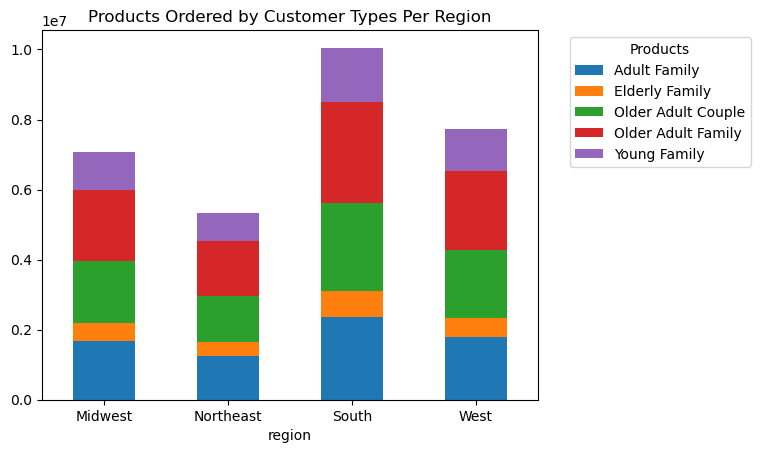

In [56]:
plt.clf()
items = df_high_activity.groupby(['region','profile']).size().unstack().plot(rot = 0, kind = 'bar', stacked = True, title = ("Products Ordered by Customer Types Per Region"))
items = items.legend(title='Products', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [58]:
items.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_cust_types.png'), bbox_inches = "tight")

<Figure size 640x480 with 0 Axes>

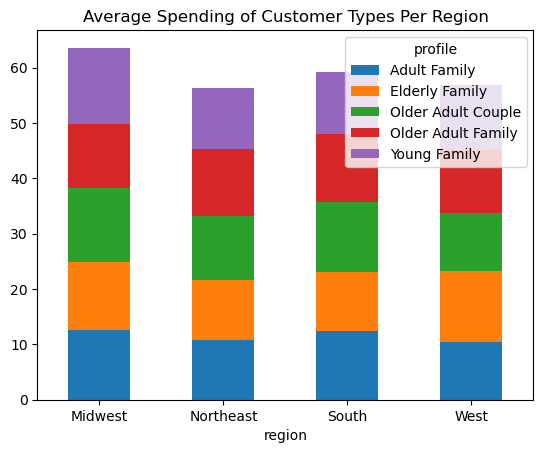

In [35]:
plt.clf()
spending = df_high_activity.groupby(['region','profile'])['avg_spending'].mean().unstack().plot(rot =0, kind = 'bar', stacked = True, title = ("Average Spending of Customer Types Per Region"))
plt.show()

There is a very different distribution amongst the regions. The midwest and south has higher spending with older adult couples while the northeast has the highest spending in adult families and the west has the highest spending amongst Young Families.

In [36]:
spending.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_avg_spending_per_region_profile.png'),  bbox_inches = "tight")

In [42]:
df_high_activity.groupby(['region','profile']).agg({'median_order_frequency': ['max', 'mean', 'min']})

median_order_frequency               
                                                max      mean  min
region    profile                                                 
Midwest   Adult Family                         30.0  9.681044  0.0
          Elderly Family                       30.0  9.927736  0.0
          Older Adult Couple                   30.0  9.622060  0.0
          Older Adult Family                   30.0  9.878882  0.0
          Young Family                         30.0  9.840980  0.0
Northeast Adult Family                         30.0  9.702773  0.0
          Elderly Family                       30.0  9.408372  0.0
          Older Adult Couple                   30.0  9.743861  0.0
          Older Adult Family                   30.0  9.737775  0.0
          Young Family                         30.0  9.507475  0.0
South     Adult Family                         30.0  9.694204  0.0
          Elderly Family                       30.0  9.599979  1.0
          Older Adult Couple                   30.0  9.725370  0.0
          Older Adult Family                   30.0  9.779654  0.0
          Young Family                         30.0  9.616549  0.0
West      Adult Family                         30.0  9.626867  0.0
          Elderly Family                       30.0  9.962379  0.0
          Older Adult Couple                   30.0  9.632702  0.0
          Older Adult Family                   30.0  9.657538  0.0
          Young Family                         30.0  9.739526  0.0

<Figure size 640x480 with 0 Axes>

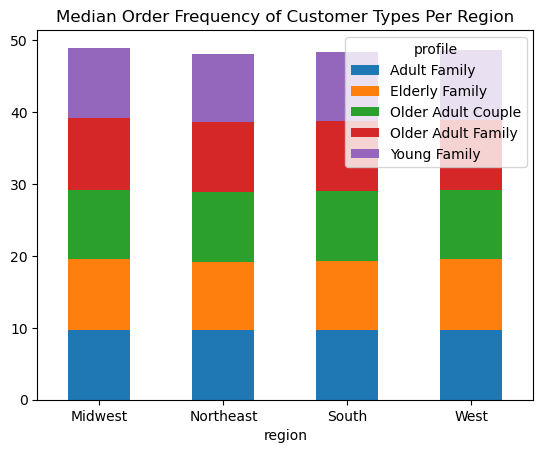

In [39]:
plt.clf()
orderfreq = df_high_activity.groupby(['region','profile'])['median_order_frequency'].mean().unstack().plot(kind = 'bar', rot = 0,stacked = True, title = ("Median Order Frequency of Customer Types Per Region"))
plt.show()

In [40]:
orderfreq.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_order_freq_per_region_profile.png'))

Median Order frequency is very similar across profiles and regions.

### Income

In [46]:
df_high_activity.agg({'income': ['max', 'mean', 'min']})

,income
max,593901.000000
mean,99770.198929
min,25903.000000


I will create the following income profiles

- 0 - 70,000: low income
- 70,000 - 120,000: median income
- 120,000+: high income

In [19]:
df_high_activity.loc[(df_high_activity['income'] <= 70000), 'income_profile'] = 'Low Income' 
df_high_activity.loc[(df_high_activity['income'] > 70000) & (df_high_activity['income'] <= 120000), 'income_profile'] = 'Median Income' 
df_high_activity.loc[(df_high_activity['income'] > 120000) , 'income_profile'] = 'High Income'
df_high_activity['income_profile'].value_counts(dropna = False)

income_profile
Median Income    12939304
High Income       8958197
Low Income        8273923
Name: count, dtype: int64

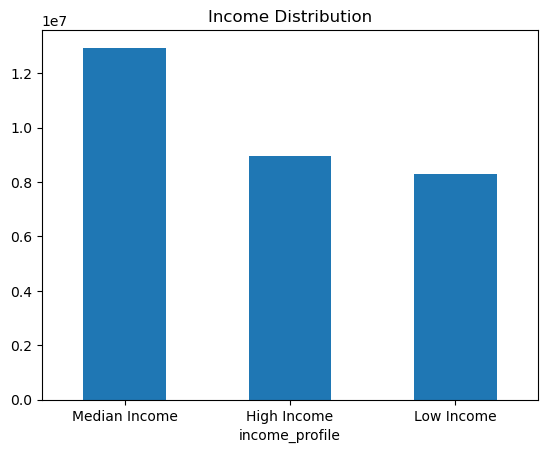

In [45]:
plt.clf()
incomebar = df_high_activity['income_profile'].value_counts().plot.bar(title = 'Income Distribution', rot = 0)
plt.show()

In [47]:
incomebar.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_income.png'))

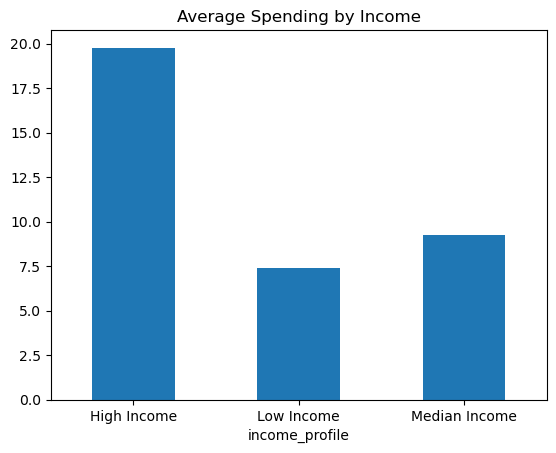

In [49]:
plt.clf()
incomespending = df_high_activity.groupby(['income_profile'])['avg_spending'].mean().plot(kind = 'bar', rot = 0, stacked = True, title = ("Average Spending by Income"))
plt.show()

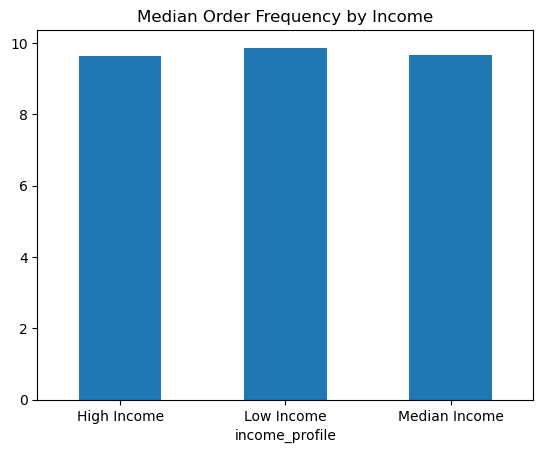

In [51]:
plt.clf()
incomeorderfreq = df_high_activity.groupby(['income_profile'])['median_order_frequency'].mean().plot(kind = 'bar', rot = 0, stacked = True, title = ("Median Order Frequency by Income"))
plt.show()

In [53]:
incomespending.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_income_spending.png'))
incomeorderfreq.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_income_orderfreq.png'))

Median order frequency is the same per income. High income earners have the highest average spending but there are more median earner customers.

### Ages

In [21]:
df_high_activity.loc[(df_high_activity['age'] >= 18) & (df_high_activity['age'] <= 30), 'age_profile'] = 'Young Adult' 
df_high_activity.loc[(df_high_activity['age'] >= 31) & (df_high_activity['age'] <= 50), 'age_profile'] = 'Adult' 
df_high_activity.loc[(df_high_activity['age'] >= 51) & (df_high_activity['age'] <= 75), 'age_profile'] = 'Older Adult' 
df_high_activity.loc[(df_high_activity['age'] >= 76), 'age_profile'] = 'Elder' 

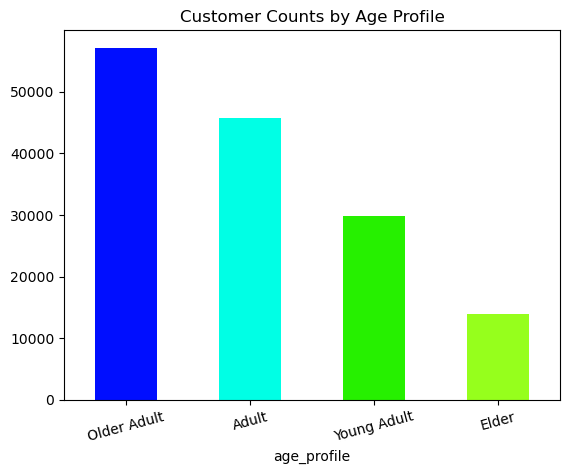

In [30]:
bar_age = df_high_activity.groupby('age_profile')['user_id'].nunique().sort_values(ascending = False).plot.bar(title = 'Customer Counts by Age Profile', rot = 15, color = palette)
plt.show()

Older Adults are the highest demographic of user.

In [36]:
bar_age.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_age_profiles.png'), bbox_inches = "tight")

In [34]:
df_high_activity['age_profile'].value_counts()

age_profile
Older Adult    11725625
Adult           9460742
Young Adult     6143408
Elder           2841649
Name: count, dtype: int64

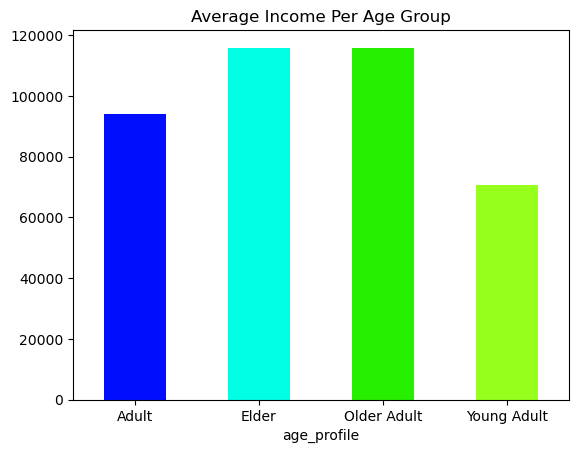

In [66]:
plt.clf()
ageincome = df_high_activity.groupby('age_profile')['income'].mean().plot.bar(title = 'Average Income Per Age Group', color = palette,rot = 0)
plt.show()

In [68]:
ageincome.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_age_avgincome.png'), bbox_inches = "tight")

Older adults and elders have the highest income. Older adults make up the largest proportion of customers while elderly make up the smallest. While income may play a factor in why Older Adults are such a strong customer bases I believe that there may be a technology barrier for elderly people to use the app. Not only that but Instacart is geared to a younger population.

# 05 More Visualization

In [23]:
dep_df.rename(columns = {'Unnamed: 0':'department_id'}, inplace = True)

In [25]:
dep = df_high_activity['department_id'].value_counts().plot.bar(title = 'Department Purchase Frequency')

In [26]:
dept_ids = df_high_activity['department_id'].value_counts().index
x_labels = []

In [29]:
for dept_id in dept_ids:
    matching_dept = dep_df.loc[dep_df['department_id'] == dept_id]
    if len(matching_dept) > 0:
        x_labels.append(matching_dept['department'].iloc[0])
    else:
        x_labels.append(str(dept_id))

In [31]:
dep.set_xticklabels(x_labels, rotation=45, ha='right')

[Text(0, 0, 'produce'),
 Text(1, 0, 'dairy eggs'),
 Text(2, 0, 'snacks'),
 Text(3, 0, 'beverages'),
 Text(4, 0, 'frozen'),
 Text(5, 0, 'pantry'),
 Text(6, 0, 'bakery'),
 Text(7, 0, 'canned goods'),
 Text(8, 0, 'deli'),
 Text(9, 0, 'dry goods pasta'),
 Text(10, 0, 'household'),
 Text(11, 0, 'meat seafood'),
 Text(12, 0, 'breakfast'),
 Text(13, 0, 'personal care'),
 Text(14, 0, 'babies'),
 Text(15, 0, 'international'),
 Text(16, 0, 'alcohol'),
 Text(17, 0, 'pets'),
 Text(18, 0, 'missing'),
 Text(19, 0, 'other'),
 Text(20, 0, 'bulk')]

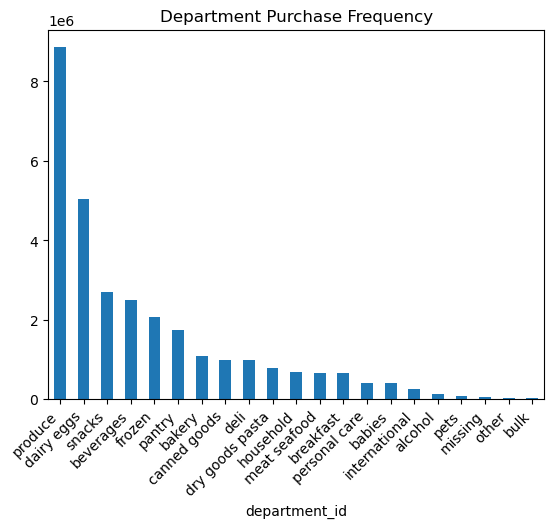

In [33]:
plt.show()

In [67]:
dep.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'dept_freq.png'),  bbox_inches = "tight")

In [68]:
len(df_high_activity[df_high_activity['department_id'] == 4])/len(df_high_activity)

0.29365349146265024

Produce makes up 29.36% of purchases.

C:\Users\isava\AppData\Local\Temp\ipykernel_10684\606503120.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lyty = df_high_activity.groupby(['loyalty_flag', 'profile']).size().unstack(fill_value=0).plot(kind = 'bar', stacked = True, rot = 0 , title = ("Loyalty by Profile"))


<Figure size 640x480 with 0 Axes>

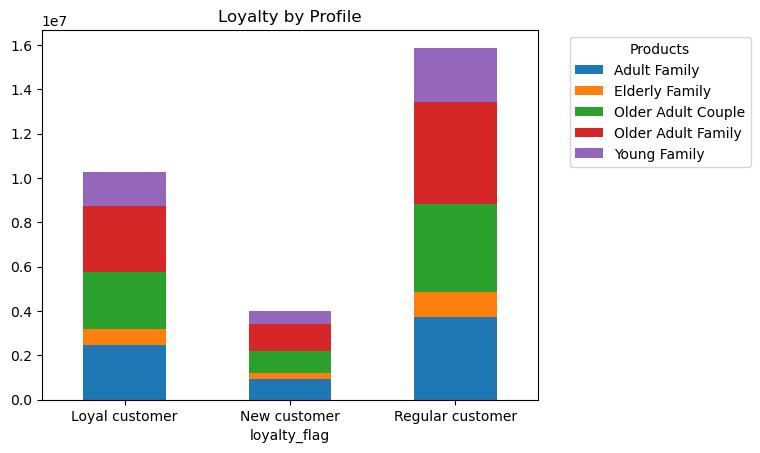

In [50]:
plt.clf()
lyty = df_high_activity.groupby(['loyalty_flag', 'profile']).size().unstack(fill_value=0).plot(kind = 'bar', stacked = True, rot = 0 , title = ("Loyalty by Profile"))
lyty = lyty.legend(title='Products', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [51]:
lyty.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'lyty_by_prfl.png'),bbox_inches = "tight")

C:\Users\isava\AppData\Local\Temp\ipykernel_15188\989505892.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orderlyty = df_high_activity.groupby(['loyalty_flag'])['avg_spending'].mean().plot(kind = 'bar', rot =0, title = ("Average Spending by Customer Loyalty"))


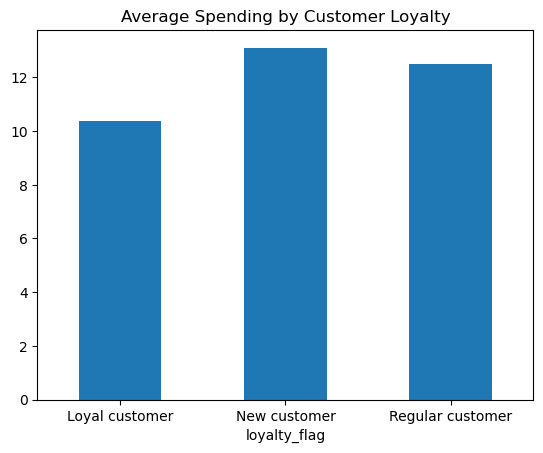

In [75]:
orderlyty = df_high_activity.groupby(['loyalty_flag'])['avg_spending'].mean().plot(kind = 'bar', rot =0, title = ("Average Spending by Customer Loyalty"))
plt.show()

In [77]:
orderlyty.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'orderlyty.png'))

In [96]:
dfsub = df_high_activity[['income_profile', 'product_name']]
df_grouped = dfsub.groupby(['income_profile', 'product_name']).size().reset_index()

0                               \
product_name   #2 Coffee Filters #2 Cone White Coffee Filters   
income_profile                                                  
High Income                205.0                          3.0   
Low Income                 216.0                          4.0   
Median Income              320.0                          6.0   

                                                                             \
product_name   #2 Mechanical Pencils #4 Natural Brown Coffee Filters #NAME?   
income_profile                                                                
High Income                      2.0                            74.0    5.0   
Low Income                       2.0                            63.0   10.0   
Median Income                    4.0                            87.0   12.0   

                                                       \
product_name   & Go! Hazelnut Spread + Pretzel Sticks   
income_profile                                          
High Income                                      29.0   
Low Income                                       74.0   
Median Income                                    44.0   

                                         \
product_name   'Swingtop' Premium Lager   
income_profile                            
High Income                         1.0   
Low Income                          NaN   
Median Income                       NaN   

                                                              \
product_name   (70% Juice!) Mountain Raspberry Juice Squeeze   
income_profile                                                 
High Income                                             10.0   
Low Income                                              10.0   
Median Income                                            4.0   

                                                                             \
product_name   .5\" Waterproof Tape 0 Calorie Acai Raspberry Water Beverage   
income_profile                                                                
High Income                     2.0                                    18.0   
Low Income                      2.0                                    18.0   
Median Income                   2.0                                    55.0   

                ...                                          \
product_name    ... with Twist Ties Sandwich & Storage Bags   
income_profile  ...                                           
High Income     ...                                     8.0   
Low Income      ...                                     1.0   
Median Income   ...                                    13.0   

                                                               \
product_name   with Xylitol Cinnamon 18 Sticks Sugar Free Gum   
income_profile                                                  
High Income                                              52.0   
Low Income                                              117.0   
Median Income                                            19.0   

                                                                        \
product_name   with Xylitol Island Berry Lime 18 Sticks Sugar Free Gum   
income_profile                                                           
High Income                                                  10.0        
Low Income                                                   22.0        
Median Income                                                15.0        

                                                                        \
product_name   with Xylitol Minty Sweet Twist 18 Sticks Sugar Free Gum   
income_profile                                                           
High Income                                                  14.0        
Low Income                                                    4.0        
Median Income                                                 1.0        

                                           

In [187]:
top5 = dfsub.groupby(['income_profile']).product_name.value_counts().groupby(level = 0, group_keys = False).head(5).unstack('income_profile')

income_profile,product_name,High Income,Low Income,Median Income
0,Banana,137874,108832,195782
1,Bag of Organic Bananas,103998,100044,155121
2,Organic Strawberries,74373,65154,111606
3,Organic Baby Spinach,68630,57412,100278
4,Organic Hass Avocado,59340,53717,90159


<Figure size 640x480 with 0 Axes>

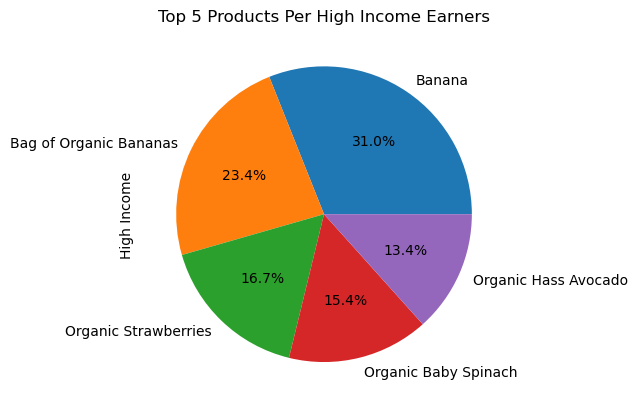

In [205]:
plt.clf()
hightop5 = top5.set_index("product_name").plot(kind = "pie", y = "High Income", autopct = "%1.1f%%", title = "Top 5 Products Per High Income Earners", legend = False)
plt.show()

<Figure size 640x480 with 0 Axes>

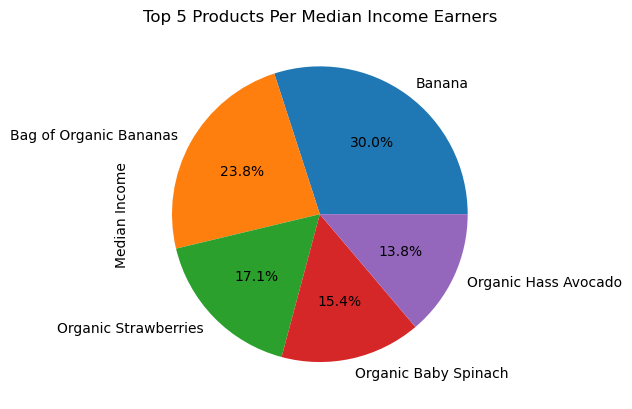

In [211]:
plt.clf()
medtop5 = top5.set_index("product_name").plot(kind = "pie", y = "Median Income", autopct = "%1.1f%%", title = "Top 5 Products Per Median Income Earners", legend = False)
plt.show()

<Figure size 640x480 with 0 Axes>

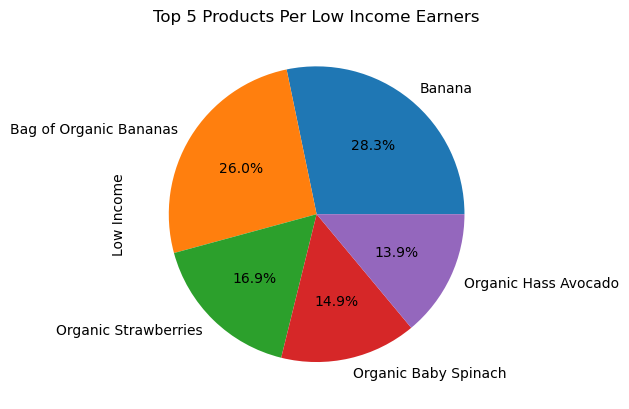

In [213]:
plt.clf()
lowtop5 = top5.set_index("product_name").plot(kind = "pie", y = "Low Income", autopct = "%1.1f%%", title = "Top 5 Products Per Low Income Earners", legend = False)
plt.show()

In [215]:
hightop5.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'top5high.png'))
medtop5.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'top5med.png'))
lowtop5.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'top5low.png'))

### Top Products Per Customer Profile and Region

In [ ]:
dfsubcust = df_high_activity[['profile', 'product_name', 'region']]
top_products = dfsubcust.groupby(['profile', 'region'])['product_name'].value_counts().groupby(level=[0,1], group_keys=False).head(5)
top_products = top_products.reset_index()

In [36]:
top_products.head()

,profile,region,product_name,count
0,Adult Family,Midwest,Banana,25036
1,Adult Family,Midwest,Bag of Organic Bananas,19791
2,Adult Family,Midwest,Organic Strawberries,14070
3,Adult Family,Midwest,Organic Baby Spinach,12496
4,Adult Family,Midwest,Organic Hass Avocado,11016


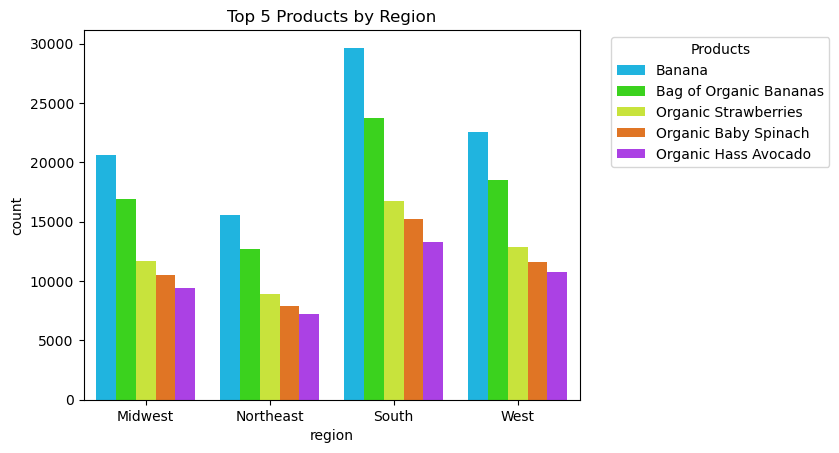

In [75]:
rgntop5 = sns.barplot(data=top_products, x='region', y='count', hue='product_name', palette='gist_ncar', errorbar = None)
rgntop5 = plt.title('Top 5 Products by Region')
rgntop5 = plt.legend(title='Products', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [77]:
rgntop5.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'rgntop5.png'),  bbox_inches = "tight")

<Figure size 640x480 with 0 Axes>

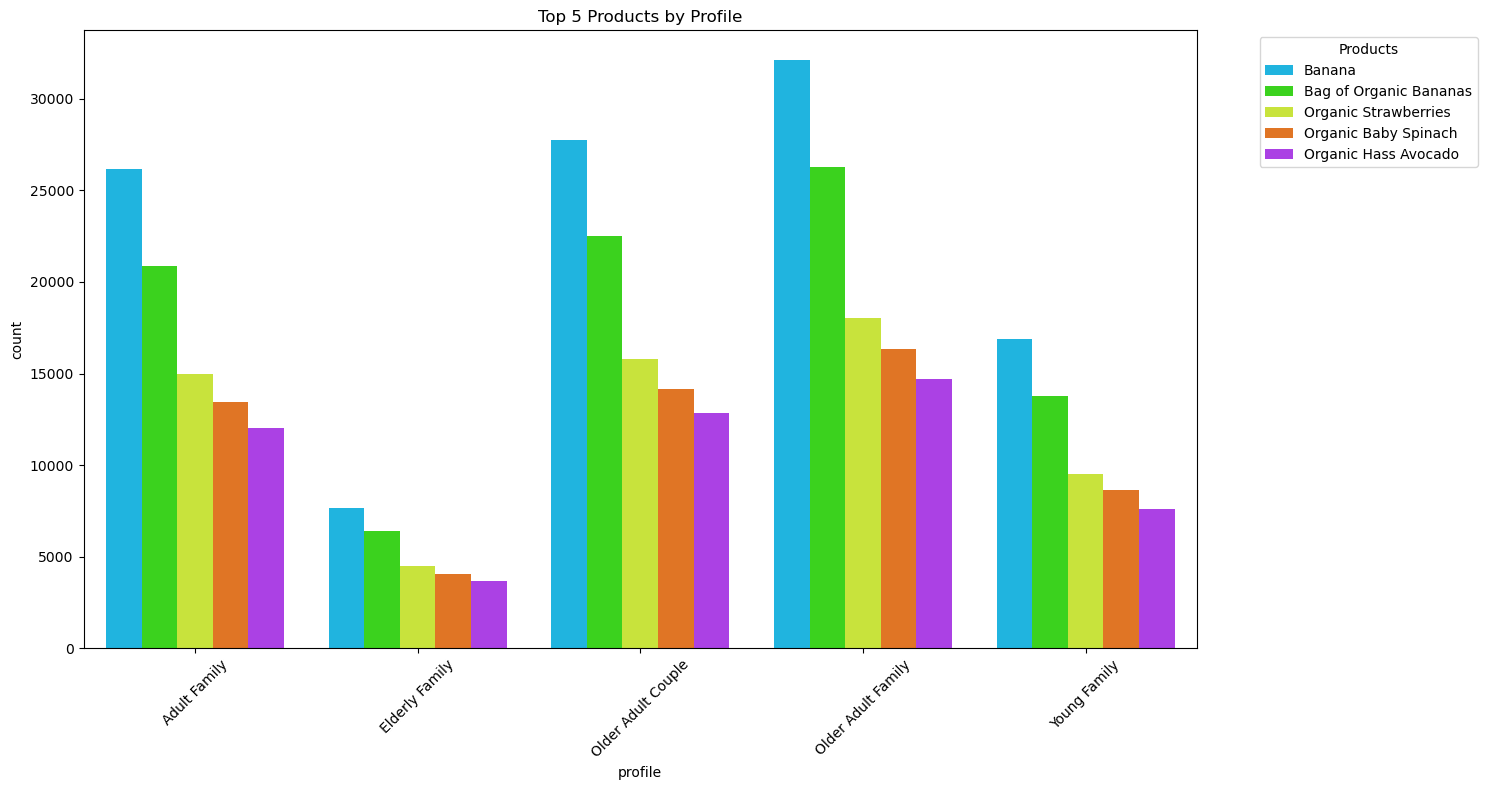

In [149]:
plt.clf()  # Clear the current figure

# Create the plot
plt.figure(figsize=(15, 8))
prtop5 = sns.barplot(data=top_products, x='profile', y='count', hue='product_name', palette='gist_ncar', errorbar=None)
plt.title('Top 5 Products by Profile')
plt.legend(title='Products', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'prtop5.png'), bbox_inches='tight')
# Show the plot
plt.show()

### Order Frequency Heatmap

In [116]:
order_summary = df_high_activity.groupby(["orders_day_of_week", "order_time_of_day"])['order_id'].nunique()
order_summary_pivot = order_summary.reset_index().pivot(index="orders_day_of_week", columns="order_time_of_day", values="order_id")

orders_day_of_week  order_time_of_day
0                   0                     3444
                    1                     2034
                    2                     1196
                    3                      808
                    4                      686
                                         ...  
6                   19                   15628
                    20                   11563
                    21                    9109
                    22                    7399
                    23                    5243
Name: order_id, Length: 168, dtype: int64

In [133]:
#Get number of orders at every hour of the day per day of the week. Counting unique orders within the hour.
order_summary_pivot = order_summary.reset_index().pivot(index="orders_day_of_week", columns="order_time_of_day", values="order_id")

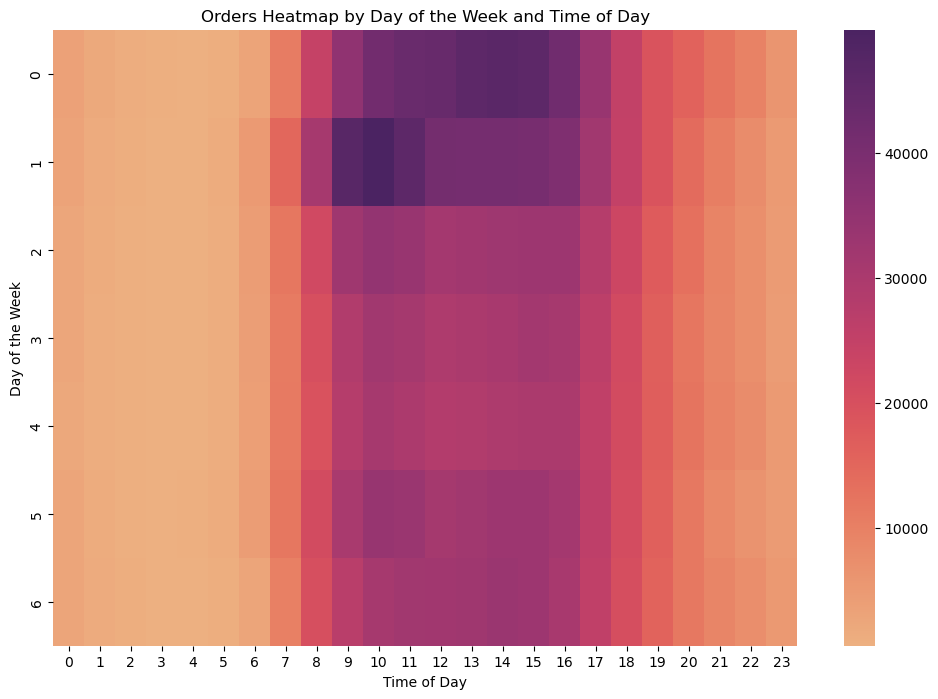

In [131]:
# Create heatmap 
plt.figure(figsize=(12, 8)) 
sns.heatmap(order_summary_pivot, annot=False, fmt="d", cmap="flare") 
# Customize the plot 
plt.title("Orders Heatmap by Day of the Week and Time of Day") 
plt.xlabel("Time of Day") 
plt.ylabel("Day of the Week")
plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'order_hm.png'), bbox_inches='tight')
plt.show()

Frequent orders happen between 8 and 4 throughout the week. The most popular days for orders are Saturdays and Sundays. On Saturday the peak hours are between noon and 3. On Sunday the peak hours are between 8 and 11. The weekends are usually when people have liesure times to plan their meals and order groceries. 

### Order Frequency - Friday

In [93]:
friday_peak_hours_orders = df_high_activity[(df_high_activity['orders_day_of_week'] == 5) & (df_high_activity['order_time_of_day'] >= 10) & (df_high_activity['order_time_of_day'] < 15)]

In [97]:
friday_peak_hours_orders.product_name.value_counts()

product_name
Banana                                                                   22113
Bag of Organic Bananas                                                   18689
Organic Strawberries                                                     12920
Organic Baby Spinach                                                     10455
Organic Hass Avocado                                                      9839
                                                                         ...  
Prepare And Serve Mashed Potatoes                                            1
Flavored with Meat Pasta Sauce                                               1
Holiday Semi-Sweet with Red & Green Colored Morsels Chocolate Morsels        1
Dark Chocolate & Mint Morsels                                                1
Lite Country French Dressing                                                 1
Name: count, Length: 38668, dtype: int64

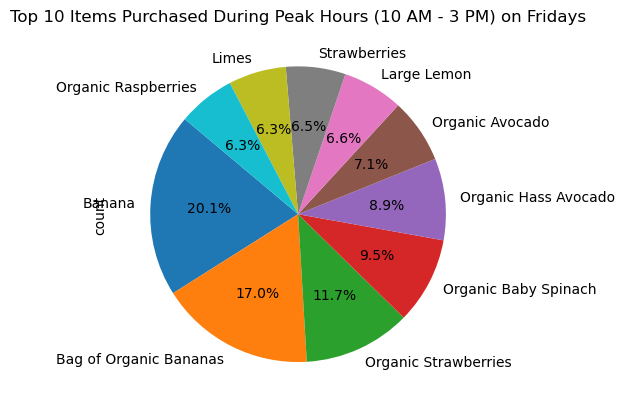

In [109]:
friday_peak_hours_orders.product_name.value_counts().head(10).plot(kind='pie', autopct='%1.1f%%', startangle=140) 
fridaytop = plt.title('Top 10 Items Purchased During Peak Hours (10 AM - 3 PM) on Fridays') 
plt.show()

In [113]:
fridaytop.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'fridaytop.png'))

### Order Frequency - Sunday

In [30]:
sunday_peak_hours_orders = df_high_activity[(df_high_activity['orders_day_of_week'] == 0) & (df_high_activity['order_time_of_day'] >= 8) & (df_high_activity['order_time_of_day'] < 11)]

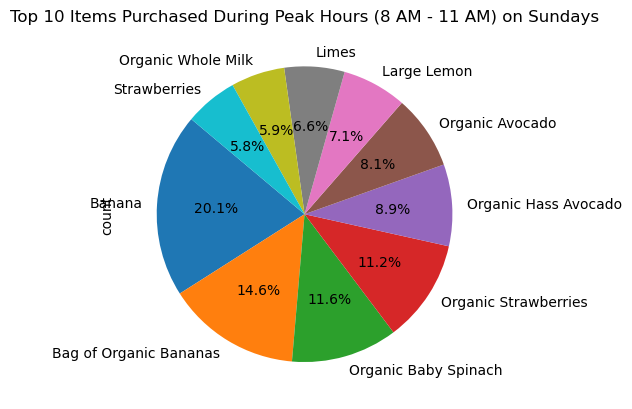

In [32]:
sunday_peak_hours_orders.product_name.value_counts().head(10).plot(kind='pie', autopct='%1.1f%%', startangle=140) 
sundaytop = plt.title('Top 10 Items Purchased During Peak Hours (8 AM - 11 AM) on Sundays') 
plt.show()

In [34]:
sundaytop.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'sundaytop.png'))

### Top Items During Early Hours of Morning

In [125]:
earlymorning_orders = df_high_activity[(df_high_activity['order_time_of_day'] >= 0) & (df_high_activity['order_time_of_day'] < 7)]

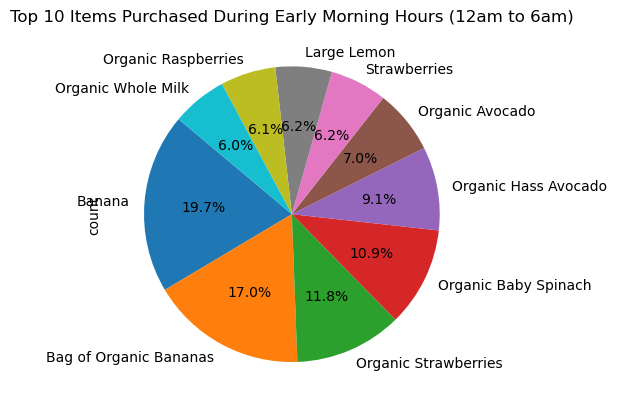

In [127]:
earlymorning_orders.product_name.value_counts().head(10).plot(kind='pie', autopct='%1.1f%%', startangle=140) 
earlytop = plt.title('Top 10 Items Purchased During Early Morning Hours (12am to 6am)') 
plt.show()

This shows the same pattern that we have been seeing - produce and dairy are the most purchased items. 

In [131]:
df_high_activity.keys()

Index(['order_id', 'user_id', 'order_number', 'orders_day_of_week',
       'order_time_of_day', 'days_since_users_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', '_merge', 'product_name', 'aisle_id',
       'department_id', 'prices', '_prodMerge', 'price_range_loc',
       'busiest_day', 'busiest_days', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'avg_spending', 'spending_flag',
       'median_order_frequency', 'order_frequency_flag', 'first_name',
       'last_name', 'gender', 'state', 'age', 'date_joined', 'n_dependents',
       'fam_status', 'income', '_custMerge', 'region', 'max_no_of_orders',
       'exclusion_flag', 'profile', 'income_profile'],
      dtype='object')

In [141]:
crosstab = pd.crosstab (df_high_activity['region'], df_high_activity['income_profile'],dropna = False)

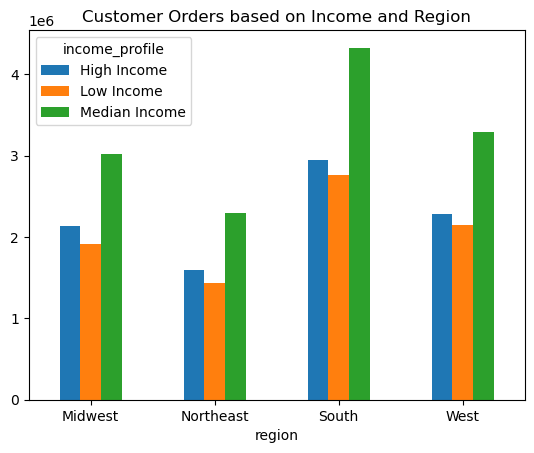

In [153]:
bar_reg_income =  crosstab.plot.bar(title = "Customer Orders based on Income and Region", rot = 0)
plt.show()

In [155]:
bar_reg_income.figure.savefig(os.path.join(path,'04 Analysis','Visualizations','bar_reg_icnome.png'))

# 05 Export Data Frame

In [46]:
df_high_activity.to_pickle(os.path.join(path, '02 Data','Prepared Data', 'high_activity.pkl'))

# 06 Appendix

## Column Descriptions

In [28]:
df_high_activity.keys()

Index(['order_id', 'user_id', 'order_number', 'orders_day_of_week',
       'order_time_of_day', 'days_since_users_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', '_merge', 'product_name', 'aisle_id',
       'department_id', 'prices', '_prodMerge', 'price_range_loc',
       'busiest_day', 'busiest_days', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'avg_spending', 'spending_flag',
       'median_order_frequency', 'order_frequency_flag', 'first_name',
       'last_name', 'gender', 'state', 'age', 'date_joined', 'n_dependents',
       'fam_status', 'income', '_custMerge', 'region', 'max_no_of_orders',
       'exclusion_flag', 'profile', 'age_profile'],
      dtype='object')

### aisle_id

In [32]:
df_high_activity['aisle_id'].nunique()

134

There are 134 different aisles.

### department_id

In [38]:
df_high_activity['department_id'].nunique()

21

There are 21 unique departments. Listed below is the key for the department names.

In [27]:
dep_df

,Unnamed: 0,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


### product_name

In [25]:
df_high_activity['product_name'].nunique()

49610

There are 49,610 unique products.

### order_id, user_id, order_number

In [57]:
df_high_activity.groupby('user_id')['order_id'].nunique()

user_id
1         10
2         14
3         12
7         20
11         7
          ..
206202    22
206206    67
206207    16
206208    49
206209    13
Name: order_id, Length: 146466, dtype: int64

In [61]:
df_high_activity.groupby('user_id')['order_id'].nunique().sum()

2983553

In [77]:
df_high_activity['order_number'].describe()

count    3.017142e+07
mean     1.822380e+01
std      1.769653e+01
min      1.000000e+00
25%      6.000000e+00
50%      1.200000e+01
75%      2.500000e+01
max      9.900000e+01
Name: order_number, dtype: float64

- There are 206,209 different users who together made 2,983,553 orders
- There is a max of 99 orders per customer at this time. Order_Id is a unique identifier for the order.

### orders_day_of_week

In [87]:
df_high_activity['orders_day_of_week'].value_counts()

orders_day_of_week
0    5744325
1    5278055
6    4175041
5    3937100
2    3921025
3    3578050
4    3537828
Name: count, dtype: int64

| Key | Value    |
|-----|----------|
| 0   | Saturday |
| 1   | Sunday   |
| 2   | Monday   |
| 3   | Tuesday  |
| 4   | Wednesday|
| 5   | Thursday |
| 6   | Friday   |  
 	|